In [1]:
import os, time, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

np.random.seed(123)

OUT_DIR = "report_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print("Saving outputs to:", os.path.abspath(OUT_DIR))


Saving outputs to: /Users/tusharrana/AML/report_outputs


In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/321/electricityloaddiagrams20112014.zip"
ZIP_PATH = "electricityloaddiagrams20112014.zip"
TXT_NAME = "LD2011_2014.txt"

if not os.path.exists(ZIP_PATH):
    print("Downloading dataset zip...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("Downloaded:", ZIP_PATH)

if not os.path.exists(TXT_NAME):
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extract(TXT_NAME)
    print("Extracted:", TXT_NAME)

print("Ready:", TXT_NAME, "size(MB):", round(os.path.getsize(TXT_NAME) / 1e6, 1))


Ready: LD2011_2014.txt size(MB): 711.0


In [3]:
header = pd.read_csv(TXT_NAME, sep=";", nrows=0)
cols = header.columns.tolist()
date_col = cols[0]
client_cols = cols[1:]

selected_clients = client_cols[:5]
usecols = [date_col] + selected_clients
print("Using columns:", usecols)

df = pd.read_csv(TXT_NAME, sep=";", usecols=usecols, low_memory=False)
df = df.rename(columns={date_col: "timestamp"})
df["timestamp"] = pd.to_datetime(df["timestamp"])

for c in selected_clients:
    df[c] = df[c].astype(str).str.replace(",", ".", regex=False).astype(float)

df = df.set_index("timestamp").sort_index()
df["total_load_kw"] = df[selected_clients].sum(axis=1)

df = df[df["total_load_kw"] > 0].copy()

print(df.head())
print("Rows after cleaning:", len(df), "Start:", df.index.min(), "End:", df.index.max())


Using columns: ['Unnamed: 0', 'MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005']
                       MT_001     MT_002     MT_003      MT_004     MT_005  \
timestamp                                                                    
2012-01-01 00:15:00  3.807107  22.759602  77.324066  136.178862  70.731707   
2012-01-01 00:30:00  5.076142  22.759602  77.324066  136.178862  73.170732   
2012-01-01 00:45:00  3.807107  22.759602  77.324066  140.243902  69.512195   
2012-01-01 01:00:00  3.807107  22.759602  77.324066  140.243902  75.609756   
2012-01-01 01:15:00  5.076142  22.048364  77.324066  146.341463  73.170732   

                     total_load_kw  
timestamp                           
2012-01-01 00:15:00     310.801343  
2012-01-01 00:30:00     314.509403  
2012-01-01 00:45:00     313.646872  
2012-01-01 01:00:00     319.744433  
2012-01-01 01:15:00     323.960767  
Rows after cleaning: 105212 Start: 2012-01-01 00:15:00 End: 2015-01-01 00:00:00


NaNs in hourly: 0 Hourly rows: 26304


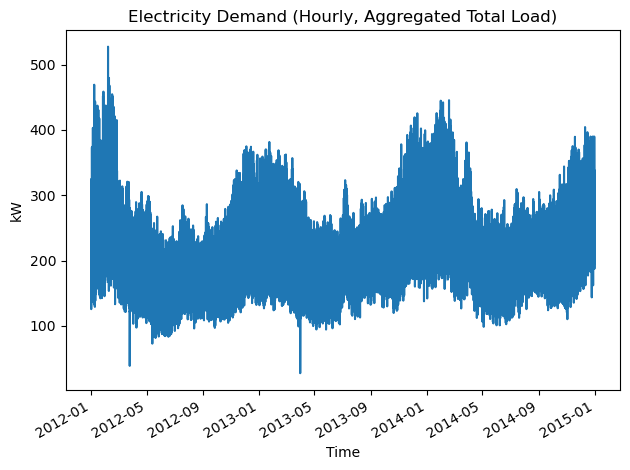

In [4]:
hourly = df["total_load_kw"].resample("h").mean().dropna()
print("NaNs in hourly:", hourly.isna().sum(), "Hourly rows:", len(hourly))

plt.figure()
hourly.plot()
plt.title("Electricity Demand (Hourly, Aggregated Total Load)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.tight_layout()
plt.show()


In [5]:
y = hourly.astype("float64")
feat = pd.DataFrame({"y": y})

LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for lag in LAGS:
    feat[f"lag_{lag}"] = feat["y"].shift(lag)

ROLLS = [3, 6, 12, 24, 168]
for w in ROLLS:
    feat[f"roll_mean_{w}"] = feat["y"].shift(1).rolling(w).mean()
    feat[f"roll_std_{w}"]  = feat["y"].shift(1).rolling(w).std()

feat["hour"] = feat.index.hour
feat["dow"] = feat.index.dayofweek
feat["month"] = feat.index.month

feat = feat.dropna()

X = feat.drop(columns=["y"])
y = feat["y"]

print("X shape:", X.shape, "y shape:", y.shape)
print("NaNs in X:", X.isna().sum().sum(), "NaNs in y:", y.isna().sum())


X shape: (26136, 22) y shape: (26136,)
NaNs in X: 0 NaNs in y: 0


In [6]:
n = len(feat)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val     = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test   = X.iloc[val_end:], y.iloc[val_end:]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (18295, 22) Val: (3920, 22) Test: (3921, 22)


In [7]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    return float(mean_absolute_percentage_error(y_true, y_pred) * 100)

pred_naive  = X_test["lag_1"].values
pred_snaive = X_test["lag_24"].values

baseline_results = pd.DataFrame({
    "Model": ["Naïve (lag_1)", "Seasonal Naïve (lag_24)"],
    "Test_RMSE": [rmse(y_test, pred_naive), rmse(y_test, pred_snaive)],
    "Test_MAPE_%": [mape(y_test, pred_naive), mape(y_test, pred_snaive)],
    "Training_Time_Seconds": [0.0, 0.0],
    "Epochs_Trained": [None, None]
})

baseline_results


,Model,Test_RMSE,Test_MAPE_%,Training_Time_Seconds,Epochs_Trained
0,Naïve (lag_1),23.908440,8.122355,0.0,None
1,Seasonal Naïve (lag_24),22.195622,7.649531,0.0,None


In [8]:
ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=123))
])

t0 = time.time()
ridge_pipe.fit(X_train, y_train)
time_ridge = time.time() - t0

pred_ridge = ridge_pipe.predict(X_test)

ridge_results = pd.DataFrame({
    "Model": ["Ridge Regression"],
    "Test_RMSE": [rmse(y_test, pred_ridge)],
    "Test_MAPE_%": [mape(y_test, pred_ridge)],
    "Training_Time_Seconds": [time_ridge],
    "Epochs_Trained": [None]
})

ridge_results


,Model,Test_RMSE,Test_MAPE_%,Training_Time_Seconds,Epochs_Trained
0,Ridge Regression,14.004987,4.981346,0.026357,None


In [9]:
def train_mlp(hidden_layers, alpha=1e-4, lr=1e-3, max_iter=8000):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=hidden_layers,
            activation="relu",
            solver="adam",
            alpha=alpha,
            learning_rate_init=lr,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=30,
            tol=1e-4,
            max_iter=max_iter,
            random_state=123
        ))
    ])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    epochs = pipe.named_steps["mlp"].n_iter_
    return pipe, train_time, epochs

simple_mlp, time_simple, ep_simple = train_mlp((32,), alpha=1e-4, lr=1e-3, max_iter=8000)
complex_mlp, time_complex, ep_complex = train_mlp((128, 64), alpha=1e-4, lr=5e-4, max_iter=12000)

pred_simple = simple_mlp.predict(X_test)
pred_complex = complex_mlp.predict(X_test)

mlp_results = pd.DataFrame({
    "Model": ["Simple MLP (32)", "Complex MLP (128,64)"],
    "Test_RMSE": [rmse(y_test, pred_simple), rmse(y_test, pred_complex)],
    "Test_MAPE_%": [mape(y_test, pred_simple), mape(y_test, pred_complex)],
    "Training_Time_Seconds": [time_simple, time_complex],
    "Epochs_Trained": [ep_simple, ep_complex]
})

mlp_results


,Model,Test_RMSE,Test_MAPE_%,Training_Time_Seconds,Epochs_Trained
0,Simple MLP (32),12.468451,4.516964,2.627316,358
1,"Complex MLP (128,64)",11.856608,4.317130,25.794358,319


In [10]:
param_grid = {
    "mlp__hidden_layer_sizes": [(64,32), (128,64), (256,128), (128,128,64)],
    "mlp__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "mlp__learning_rate_init": [1e-4, 3e-4, 1e-3, 3e-3]
}

tuned_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        activation="relu",
        solver="adam",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        tol=1e-4,
        max_iter=12000,
        random_state=123
    ))
])

tscv = TimeSeriesSplit(n_splits=3)

search = RandomizedSearchCV(
    tuned_pipe,
    param_distributions=param_grid,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=123,
    n_jobs=-1
)

t0 = time.time()
search.fit(X_train, y_train)
time_tuned = time.time() - t0

best_model = search.best_estimator_
best_params = search.best_params_

pred_tuned = best_model.predict(X_test)
ep_tuned = best_model.named_steps["mlp"].n_iter_

tuned_results = pd.DataFrame({
    "Model": ["Tuned MLP (Auto)"],
    "Test_RMSE": [rmse(y_test, pred_tuned)],
    "Test_MAPE_%": [mape(y_test, pred_tuned)],
    "Training_Time_Seconds": [time_tuned],
    "Epochs_Trained": [ep_tuned]
})

print("Best params:", best_params)
tuned_results


Best params: {'mlp__learning_rate_init': 0.003, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__alpha': 0.01}


,Model,Test_RMSE,Test_MAPE_%,Training_Time_Seconds,Epochs_Trained
0,Tuned MLP (Auto),11.97924,4.359003,95.765094,167


In [11]:
results_all = pd.concat([baseline_results, ridge_results, mlp_results, tuned_results], ignore_index=True)
table1_path = os.path.join(OUT_DIR, "Table1_All_Model_Comparison.csv")
results_all.to_csv(table1_path, index=False)

results_all


,Model,Test_RMSE,Test_MAPE_%,Training_Time_Seconds,Epochs_Trained
0,Naïve (lag_1),23.908440,8.122355,0.000000,None
1,Seasonal Naïve (lag_24),22.195622,7.649531,0.000000,None
2,Ridge Regression,14.004987,4.981346,0.026357,None
3,Simple MLP (32),12.468451,4.516964,2.627316,358
4,"Complex MLP (128,64)",11.856608,4.317130,25.794358,319
5,Tuned MLP (Auto),11.979240,4.359003,95.765094,167


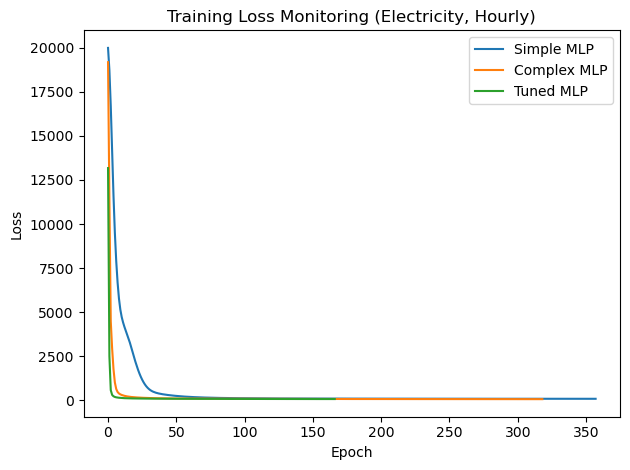

Saved: report_outputs/Figure1_Loss_Monitoring_Electricity.png


In [12]:
plt.figure()
plt.plot(simple_mlp.named_steps["mlp"].loss_curve_, label="Simple MLP")
plt.plot(complex_mlp.named_steps["mlp"].loss_curve_, label="Complex MLP")
plt.plot(best_model.named_steps["mlp"].loss_curve_, label="Tuned MLP")
plt.title("Training Loss Monitoring (Electricity, Hourly)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

fig1_path = os.path.join(OUT_DIR, "Figure1_Loss_Monitoring_Electricity.png")
plt.savefig(fig1_path, dpi=200)
plt.show()

print("Saved:", fig1_path)


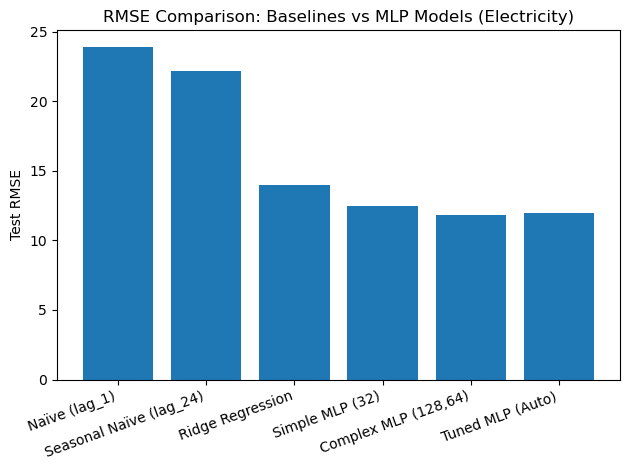

Saved: report_outputs/Figure2_RMSE_Comparison_Electricity.png
Saved: report_outputs/Table1_All_Model_Comparison.csv


In [13]:
plt.figure()
plt.bar(results_all["Model"], results_all["Test_RMSE"])
plt.title("RMSE Comparison: Baselines vs MLP Models (Electricity)")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig2_path = os.path.join(OUT_DIR, "Figure2_RMSE_Comparison_Electricity.png")
plt.savefig(fig2_path, dpi=200)
plt.show()

print("Saved:", fig2_path)
print("Saved:", table1_path)


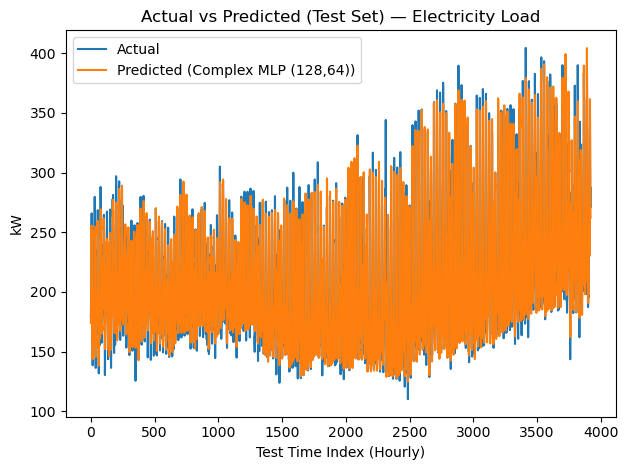

Saved: report_outputs/Figure3_Actual_vs_Predicted_Electricity.png
Best model: Complex MLP (128,64)


In [14]:
best_name = results_all.sort_values("Test_RMSE").iloc[0]["Model"]

pred_map = {
    "Naïve (lag_1)": pred_naive,
    "Seasonal Naïve (lag_24)": pred_snaive,
    "Ridge Regression": pred_ridge,
    "Simple MLP (32)": pred_simple,
    "Complex MLP (128,64)": pred_complex,
    "Tuned MLP (Auto)": pred_tuned
}

best_pred = pred_map[best_name]

plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(best_pred, label=f"Predicted ({best_name})")
plt.title("Actual vs Predicted (Test Set) — Electricity Load")
plt.xlabel("Test Time Index (Hourly)")
plt.ylabel("kW")
plt.legend()
plt.tight_layout()

fig3_path = os.path.join(OUT_DIR, "Figure3_Actual_vs_Predicted_Electricity.png")
plt.savefig(fig3_path, dpi=200)
plt.show()

print("Saved:", fig3_path)
print("Best model:", best_name)
